DistilBERT for Sentiment Analysis

In [1]:
# install requirements
%cd D7047E-Lab1
!pip install -r requirements.txt

/home/jovyan/Group7_Lab1/D7047E-Lab1


In [2]:
import os
import wandb
import torch, gc
import time
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, TrainerCallback, EarlyStoppingCallback
from transformers import DataCollatorWithPadding
from transformers import DistilBertForSequenceClassification
import evaluate
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Load local config constants
from config import NUM_LABELS, WANDB_PROJECT, SEED, SPLIT_RATIOS
from data_pipeline import load_and_split, prepare_transformer_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 1. Wandb login
os.environ["WANDB_PROJECT"] = "D7047E-Lab1"
os.environ["WANDB_NAME"] = "distilbert-1gb-run"
os.environ["WANDB_DISABLED"] = "false"
wandb.login()
# 2. Reset the GPU Cache 
gc.collect()
torch.cuda.empty_cache()

In [4]:
model_name = "distilbert-base-uncased"
SUBSET_SIZE = 2800000 # 2.8 million rows
print(f"Loading {SUBSET_SIZE} records")
data_splits = load_and_split(subset_size=SUBSET_SIZE, seed=SEED, split_ratios=SPLIT_RATIOS)
lengths = [len(text.split()) for text in data_splits["train"]["texts"][:10000]] # Checking the first 10k rows
print(f"Average length: {np.mean(lengths):.2f}")
print(f"95th percentile: {np.percentile(lengths, 95):.2f}")
print(f"Max length in sample: {max(lengths)}")

# Calculating the exact size of loaded text in memory
total_bytes = 0

# Looping through Train, Val, and Test splits and count the UTF-8 bytes
for split in ["train", "val", "test"]:
    total_bytes += sum(len(str(text).encode('utf-8')) for text in data_splits[split]["texts"])

# Converting bytes to Gigabytes (1 GB = 1024^3 bytes)
size_in_gb = total_bytes / (1024 ** 3)

print(f"Total Records Loaded: {SUBSET_SIZE}")
print(f"Total Text Data Size: {size_in_gb:.3f} GB")
print("Tokenizing using the shared pipeline")
tokenized_train = prepare_transformer_dataset(data_splits["train"]["texts"], data_splits["train"]["labels"], model_name)
tokenized_val = prepare_transformer_dataset(data_splits["val"]["texts"], data_splits["val"]["labels"], model_name)
tokenized_test = prepare_transformer_dataset(data_splits["test"]["texts"], data_splits["test"]["labels"], model_name)
small_val_dataset = tokenized_val.shuffle(seed=42).select(range(5000))

print("Data ready!")

Loading 2800000 records


Average length: 73.64
95th percentile: 155.00
Max length in sample: 204
Total Records Loaded: 2800000
Total Text Data Size: 1.056 GB
Tokenizing using the shared pipeline


Map: 100%|██████████| 280000/280000 [00:34<00:00, 8143.88 examples/s] 


Data ready!


In [5]:
model_name = "distilbert-base-uncased"

print("Initializing DistilBERT")
data_collator = DataCollatorWithPadding(tokenizer=AutoTokenizer.from_pretrained(model_name))
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_LABELS)

# Define Metrics
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return clf_metrics.compute(predictions=predictions, references=labels)

class CustomLoggingCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if "loss" in logs:
                print(f"Step {state.global_step}: Loss {logs['loss']:.4f}")
                
# Training Arguments
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    learning_rate=4e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,    
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=1000,
    save_steps=1000,
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=["wandb"],               
    logging_steps=1000,
    fp16=True, 
    disable_tqdm=False,
    push_to_hub=False,
    log_level="info",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=small_val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[CustomLoggingCallback(), EarlyStoppingCallback(early_stopping_patience=5)],
)

print("Starting Training")
start_time = time.time()
trainer.train()
end_time = time.time()

print(f"Training completed in {(end_time - start_time)/60:.2f} minutes.")

Initializing DistilBERT


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4013.65it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The following columns in the Training set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: token_type_ids.

Starting Training


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: shravanikuchi (shravanikuchi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1000,0.877023,0.183357,0.928200,0.930332,0.920861,0.940000
2000,0.683408,0.163231,0.937800,0.938622,0.944776,0.932549
3000,0.640715,0.162652,0.944000,0.944598,0.953275,0.936078
4000,0.604968,0.169785,0.940200,0.939730,0.966819,0.914118
5000,0.601460,0.161210,0.943800,0.945192,0.940241,0.950196
6000,0.581957,0.153041,0.944200,0.944851,0.952571,0.937255
7000,0.560456,0.141719,0.948800,0.949307,0.958800,0.940000
8000,0.559146,0.143652,0.950800,0.951422,0.958234,0.944706
9000,0.553823,0.141831,0.948800,0.949166,0.961384,0.937255
10000,0.535147,0.138883,0.947400,0.948218,0.952155,0.944314


...

Step 39000: Loss 0.3613


Saving model checkpoint to ./distilbert_results/checkpoint-39000
Configuration saved in ./distilbert_results/checkpoint-39000/config.json
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.93it/s]
Model weights saved in ./distilbert_results/checkpoint-39000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./distilbert_results/checkpoint-39000/tokenizer_config.json
The following columns in the Evaluation set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: token_type_ids. If token_type_ids are not expected by `DistilBertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 5000
  Batch size = 16


Step 40000: Loss 0.3587


Saving model checkpoint to ./distilbert_results/checkpoint-40000
Configuration saved in ./distilbert_results/checkpoint-40000/config.json
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]
Model weights saved in ./distilbert_results/checkpoint-40000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./distilbert_results/checkpoint-40000/tokenizer_config.json


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from ./distilbert_results/checkpoint-35000 (score: 0.11681877076625824).
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training completed in 133.71 minutes.


The following columns in the test set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: token_type_ids. If token_type_ids are not expected by `DistilBertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Prediction *****
  Num examples = 280000
  Batch size = 16


Running final test set evaluation



FINAL DISTILBERT PERFORMANCE
Test Accuracy:  0.9609
Test F1 Score:  0.9607
Test Precision: 0.9643
Test Recall:    0.9572


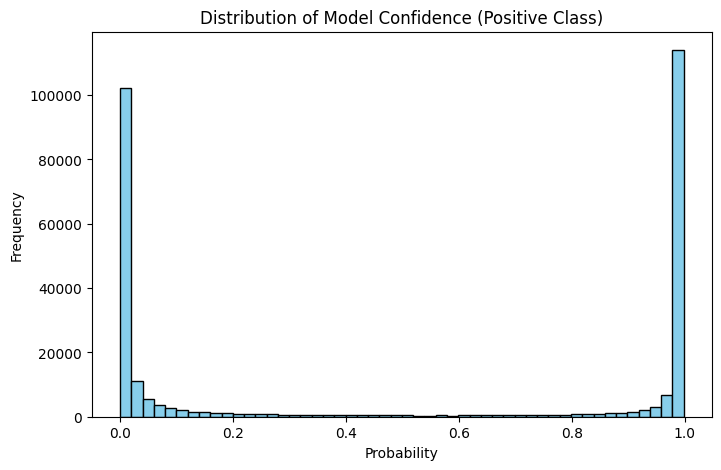

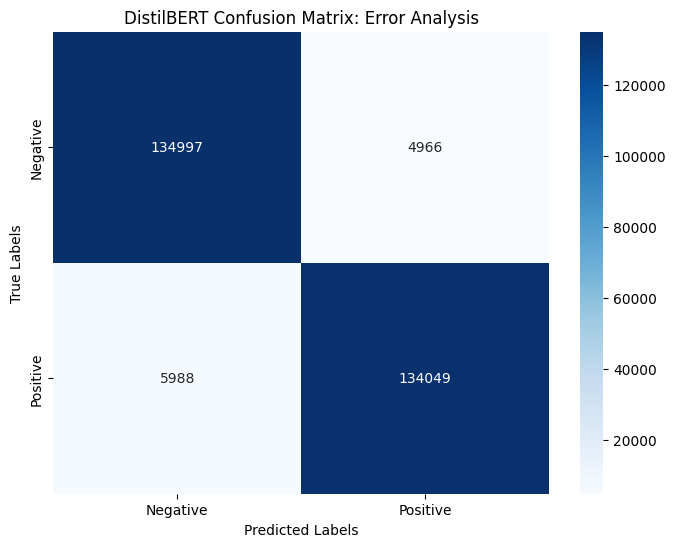


ERROR ANALYSIS SUMMARY
True Negatives (Correct): 134997
True Positives (Correct): 134049
False Positives: 4966
False Negatives: 5988

--- TOP FALSE POSITIVES (Model thought Positive, was actually Negative) ---
<ArrowStringArray>
[                      'I always look at the negative reviews first, so if you are reading this, then I assume that you do the same.I judge a music album by 3 criteria....does it blow my hair back the first few times I listen to it?, do I skip tracks, or listen to the album through?, and can it stand the test of time?The first time I heard this album was 13 years ago. I was 14 at the time. It totally blew my hair back, and I couldnt stop listening to it. No tracks were skipped (ok, maybe just `television`)13 years later, and probably about 80 other ``punk`` albums owned and thouroughly listened to, I have not gotten tired of this album. This is in my top 5 best punk albums I have ever listened to.Bad religion has MANY other great albums and songs, dont get me 

eval/accuracy,▁▃▄▄▄▄▅▆▅▅▆▆▆▆▆▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇█████▇█
eval/f1,▁▃▄▃▄▄▅▆▅▅▆▆▆▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇███████
eval/loss,█▆▆▇▆▅▄▄▄▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▂▁▂▂▁▁▂▁▂▁▁
eval/precision,▁▄▅▇▄▅▆▆▇▅▆▇▆▇▆█▅▅▇▇▆▇▆▇█▆▆▇▇█▆▅█▇▇▆▇▇▇▆
eval/recall,▅▄▄▁▆▄▅▅▄▅▆▅▆▄▅▃▇▇▆▆▇▆▇▇▆█▇▇▇▆██▆▇▇█▇▇▇▇
eval/runtime,███▂▁▁▁▁▁▂▁▂▄▂▁▁▁▂▁▁▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/samples_per_second,▁▁▁▇██▇██▇▇▇▄▇█▇█▇█▇▆▆█▇██▇▇▇▇██▇▇█▇▇▇▇▇
eval/steps_per_second,▁▁▁▇██▇██▇▇▇▄▇█▇█▇█▇▆▆█▇██▇▇▇▇██▇▇█▇▇▇▇▇
test/accuracy,▁
test/f1,▁
+11,...


In [6]:
print("Running final test set evaluation")
output = trainer.predict(tokenized_test)
test_results = output.metrics

y_preds = np.argmax(output.predictions, axis=1)
y_true = output.label_ids
# Print metrics
print("\n" + "="*40 + "\nFINAL DISTILBERT PERFORMANCE\n" + "="*40)
print(f"Test Accuracy:  {test_results['test_accuracy']:.4f}")
print(f"Test F1 Score:  {test_results['test_f1']:.4f}")
print(f"Test Precision: {test_results['test_precision']:.4f}")
print(f"Test Recall:    {test_results['test_recall']:.4f}")

# Visualization 1: Distribution of Model Confidence
probs = F.softmax(torch.from_numpy(output.predictions), dim=-1).numpy()
plt.figure(figsize=(8, 5))
plt.hist(probs[:, 1], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Model Confidence (Positive Class)")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

# Visualization 2: Confusion Matrix 
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('DistilBERT Confusion Matrix: Error Analysis')
plt.show()

# Quantitative Error Analysis
tn, fp, fn, tp = cm.ravel()
print("\n" + "="*40 + "\nERROR ANALYSIS SUMMARY\n" + "="*40)
print(f"True Negatives (Correct): {tn}")
print(f"True Positives (Correct): {tp}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print("="*40)

# Qualitative Error Analysis
error_df = pd.DataFrame({
    'text': data_splits["test"]["texts"],
    'actual': y_true,
    'predicted': y_preds,
    'confidence': [probs[i][y_preds[i]] for i in range(len(y_preds))]
})

# Filter for specific errors
false_positives = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]
false_negatives = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]

# Displaying the "most confident" errors
print("\n--- TOP FALSE POSITIVES (Model thought Positive, was actually Negative) ---")
print(false_positives.sort_values(by='confidence', ascending=False).head(5)['text'].values)

print("\n--- TOP FALSE NEGATIVES (Model thought Negative, was actually Positive) ---")
print(false_negatives.sort_values(by='confidence', ascending=False).head(5)['text'].values)

# Finish session
wandb.finish()

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/config.json
Model config DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "output_attentions": true,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.5.0",
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/model.safetensors
Since the `dtype` attrib

Generating Heatmaps for the report


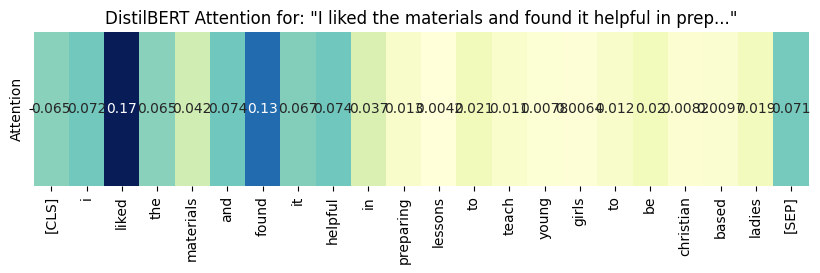

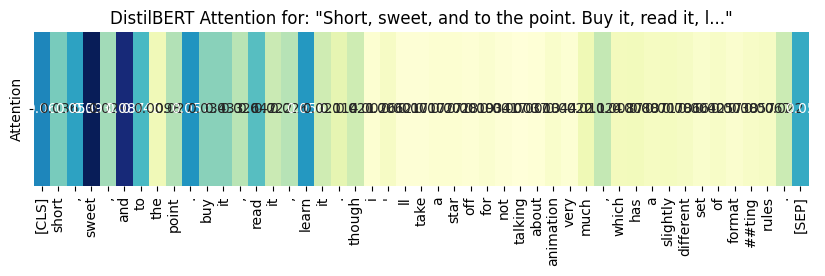

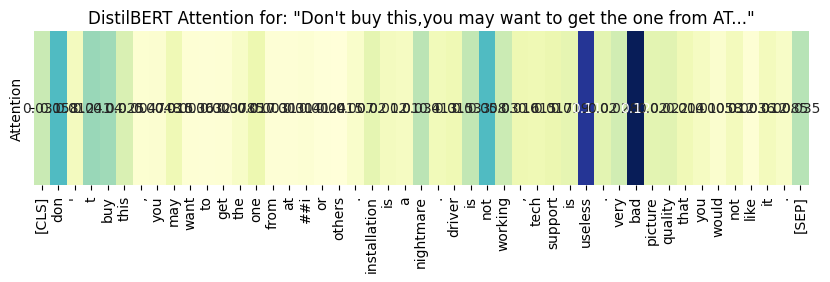

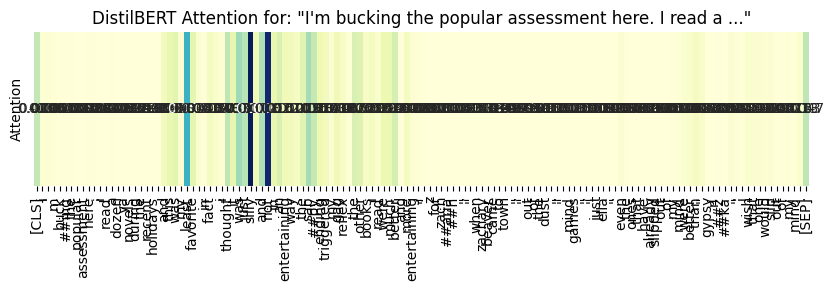

In [7]:
def visualize_attention(text, model, tokenizer):
    # 1. Preparing input
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=160).to(model.device)
    
    # 2. Getting the model outputs with attention weights
    outputs = model(**inputs, output_attentions=True)
    attention = outputs.attentions[-1] # Getting weights from the last layer
    
    # 3. Average attention across all heads
    avg_attention = attention.mean(dim=1).squeeze().detach().cpu().numpy()
    
    # 4. Tokenize for labels
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    # 5. Plot Heatmap
    plt.figure(figsize=(10, 2))
    sns.heatmap(avg_attention[0:1, :len(tokens)], xticklabels=tokens, yticklabels=["Attention"], 
                annot=True, cbar=False, cmap="YlGnBu")
    plt.title(f"DistilBERT Attention for: \"{text[:50]}...\"")
    plt.show()

# Finding the first 5 examples where the model is very confident (>95%)
model_visual = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=2,
    output_attentions=True,
    attn_implementation="eager"
).to("cuda")

model_visual.load_state_dict(trainer.model.state_dict())
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
# Generate visuals for 3 positive and 3 negative
print("Generating Heatmaps for the report")

pos_indices = np.where(probs[:, 1] > 0.98)[0][:2]
neg_indices = np.where(probs[:, 0] > 0.98)[0][:2]

for idx in list(pos_indices) + list(neg_indices):
    text = data_splits["test"]["texts"][idx]
    visualize_attention(text, model_visual, tokenizer)

In [8]:
trainer.save_model("./FINAL_SUBMISSION_MODEL")
tokenizer.save_pretrained("./FINAL_SUBMISSION_MODEL")
print("Trained model saved to ./FINAL_SUBMISSION_MODEL")

Saving model checkpoint to ./FINAL_SUBMISSION_MODEL
Configuration saved in ./FINAL_SUBMISSION_MODEL/config.json
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]
Model weights saved in ./FINAL_SUBMISSION_MODEL/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./FINAL_SUBMISSION_MODEL/tokenizer_config.json
tokenizer config file saved in ./FINAL_SUBMISSION_MODEL/tokenizer_config.json


Trained model saved to ./FINAL_SUBMISSION_MODEL
